In [ ]:
# ---------------------------------------------------------------------------
# Grayscale to binary mask converter
# ---------------------------------------------------------------------------
# This script converts a folder of grayscale TIFF slices into binary masks
# by applying a simple foreground/background threshold. Any pixel with an
# intensity greater than zero is mapped to 255 (foreground), while zero-valued
# pixels are retained as background. This step is typically applied after an
# initial segmentation stage (e.g. a neural network or region-growing tool)
# that produces labelled output with non-zero values for detected structures.
# The resulting binary masks standardise the pixel value range to uint8 and
# are suitable for downstream morphological analysis, volume quantification,
# or manual quality control.
# ---------------------------------------------------------------------------

import os
import numpy as np
import tifffile as tiff

# ---------------------------------------------------------------------------
# Configuration — replace these values before running
# ---------------------------------------------------------------------------
# Absolute path to the folder containing the input grayscale TIFF slices.
# The script expects individual 2D TIFF files (one slice per file).
input_folder = "/path/to/input/folder"

# Absolute path to the folder where binarised TIFF slices will be saved.
# The folder will be created automatically if it does not already exist.
output_folder = "/path/to/output/folder"

# ---------------------------------------------------------------------------
# Output directory setup
# ---------------------------------------------------------------------------
# exist_ok=True prevents an error if the folder already exists, making the
# script safe to re-run without manual cleanup.
os.makedirs(output_folder, exist_ok=True)

# ---------------------------------------------------------------------------
# Binarisation loop
# ---------------------------------------------------------------------------
# sorted() ensures slices are processed in alphabetical/numerical order,
# which is important for maintaining slice sequence consistency.
for filename in sorted(os.listdir(input_folder)):
    if filename.lower().endswith('.tif'):

        input_path  = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Read the 2D TIFF slice. The script assumes 16-bit grayscale input
        # (as typically produced by micro-CT or confocal imaging pipelines),
        # but will work with any integer grayscale depth.
        img = tiff.imread(input_path)

        # Apply a binary threshold: any pixel with an intensity greater than
        # zero (i.e. belonging to a segmented structure) is mapped to 255,
        # and background pixels (intensity == 0) are mapped to 0.
        # The result is cast to uint8, the standard format for binary masks,
        # where 255 = foreground and 0 = background.
        binary = np.where(img > 0, 255, 0).astype(np.uint8)

        # Save the binarised slice to the output folder, preserving the
        # original filename so that stack order is unambiguous.
        tiff.imwrite(output_path, binary)

print(f"Done: all slices in '{input_folder}' converted to binary and saved to '{output_folder}'.")

Lowest intensity of root: 5742
Highest intensity of root: 6648
Lowest intensity of sand: 5410
Highest intensity of sand: 9653


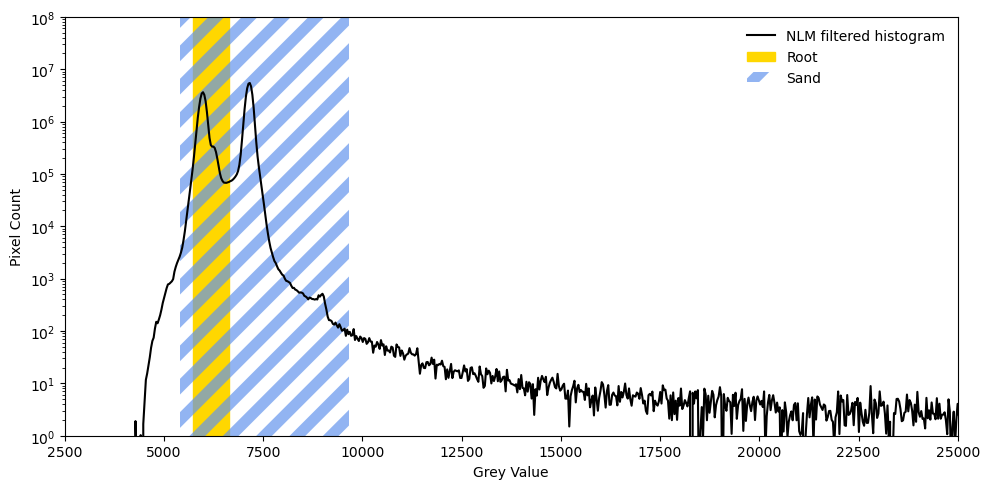

In [ ]:
import pandas as pd

import matplotlib.pyplot as plt

from scipy.interpolate import interp1d

import numpy as np

# Load CSV

hist_df = pd.read_csv("D:/Project_roothair/Python Pipeline/Filtered masks/Col_S12/Histograms/Col_S12_histogram_filtered.csv")

hist_df.columns = ['Intensity', 'Count']

root_df = pd.read_csv("D:/Project_roothair/Python Pipeline/Filtered masks/Col_S12/Histograms/Col_S12_root.csv", header=None, names=["intensity", "count"])

root_df.columns = ['Intensity', 'Count']

sand_df = pd.read_csv("D:/Project_roothair/Python Pipeline/Filtered masks/Col_S12/Histograms/Col_S12_sand.csv", header=None, names=["intensity", "count"])

sand_df.columns = ['Intensity', 'Count']


# Filter: keep only grey values where Count > 10
root_df = root_df[root_df['Count'] > 10]
sand_df = sand_df[sand_df['Count'] > 10]

# reset index for cleanliness
root_df = root_df.reset_index(drop=True)
sand_df = sand_df.reset_index(drop=True)

# Min and Max value 
lowest_root = root_df['Intensity'].min()
highest_root = root_df['Intensity'].max()

lowest_sand = sand_df['Intensity'].min()
highest_sand = sand_df['Intensity'].max()

print("Lowest intensity of root:", lowest_root)
print("Highest intensity of root:", highest_root)
print("Lowest intensity of sand:", lowest_sand)
print("Highest intensity of sand:", highest_sand)

# Interpolate to smooth the histogram curve

x = hist_df['Intensity']

y = hist_df['Count']

f = interp1d(x, y, kind='cubic')  # Smooth curve

xnew = np.linspace(x.min(), x.max(), 1000)

ynew = f(xnew)

# Plot the smoothed histogram

plt.figure(figsize=(10, 5))

plt.plot(xnew, ynew, color='black', label='NLM filtered histogram')

# Add shaded regions based on your grey value ranges

plt.axvspan(5742, 6648, color='gold', alpha=1, label='Root')

plt.axvspan(5410, 9653, facecolor='none', edgecolor='cornflowerblue', hatch="/", alpha=0.7,linewidth=0, label='Sand')
plt.rcParams['hatch.linewidth']=8

#plt.axvspan(5100, 33585, color='blue', alpha=0.2, label='Background')

# Background is everything else (not shaded, just mentioned)

# Axis labels and formatting

plt.xlabel("Grey Value")

plt.ylabel("Pixel Count")

plt.yscale('log')  # Optional: comment this out if not needed

plt.ylim(10**0, 10**8)
plt.xlim(2500,25000)

plt.legend(frameon=False, loc='upper right')

plt.tight_layout()

plt.savefig("histogram_Col_S1_small.pdf", dpi=300)

plt.show()